# Week 2: Exploratory Data Analysis (EDA)
Instead of raw data, we strictly utilize our pristine, clean dataset from Week 1 to identify the statistical driving factors behind hotel cancellations.


In [1]:
# Day 1:IMporting Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional corporate styling
sns.set_theme(style="whitegrid", palette="muted")


In [2]:
# Load our strictly cleaned dataset from Week 1!
df = pd.read_csv('cleaned_hotel_data_week1.csv')
print(f"Pristine Data Loaded! Dimensions: {df.shape}")

print("\n--- Day 1: Baseline Cancellation Rate ---")
print(df['is_canceled'].value_counts(normalize=True) * 100)


Pristine Data Loaded! Dimensions: (118673, 33)

--- Day 1: Baseline Cancellation Rate ---
is_canceled
False    62.764909
True     37.235091
Name: proportion, dtype: float64


## Day 2: Univariate Analysis (Booking Demographics)
We need to visually determine which booking channels (Online Travel Agents, Direct, Corporate) drive the highest volume of cancellations.


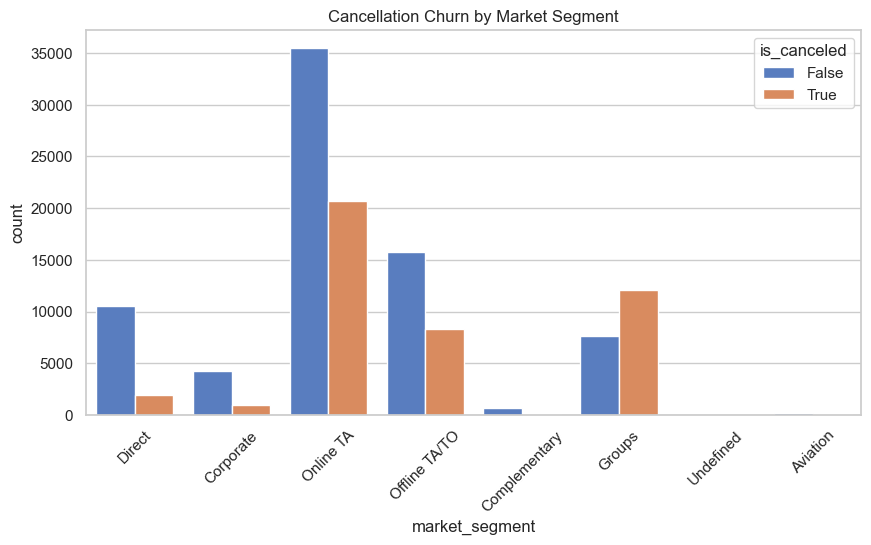

In [3]:
# Initialize the figure size and plot the churn by market segment
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='market_segment', hue='is_canceled')
# Add formatting so the chart is professional and readable
plt.title("Cancellation Churn by Market Segment")
plt.xticks(rotation=45)
plt.show()


## Day 3: Financial Impact Analysis (ADR)
We will analyze the Average Daily Rate (ADR) to determine if premium pricing correlates with a higher attrition rate.
We cap the Y-axis at $400 to remove visual distortion from luxury suites.


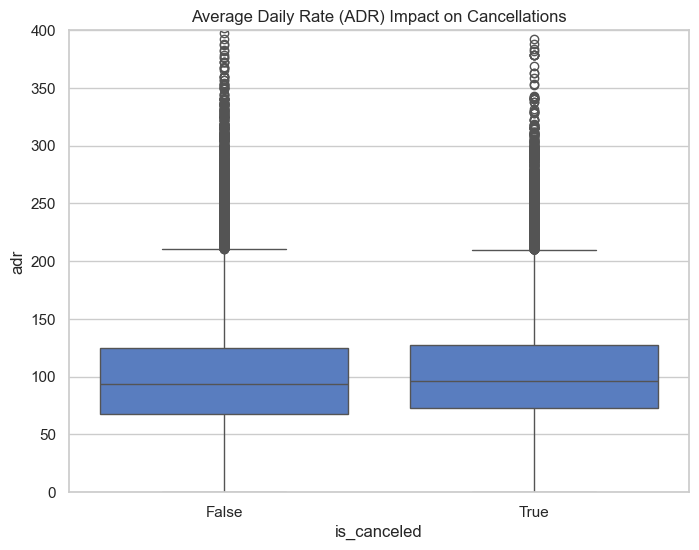

In [4]:
# Do expensive rooms cancel more often?
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='is_canceled', y='adr')

plt.title("Average Daily Rate (ADR) Impact on Cancellations")

# Limit y-axis to standard prices so the chart isn't squished
plt.ylim(0, 400) 
plt.show()


## Day 4: Correlation Heatmap
To prepare for Machine Learning, we must identify which numerical features have the highest mathematical correlation 
with the target variable (`is_canceled`).


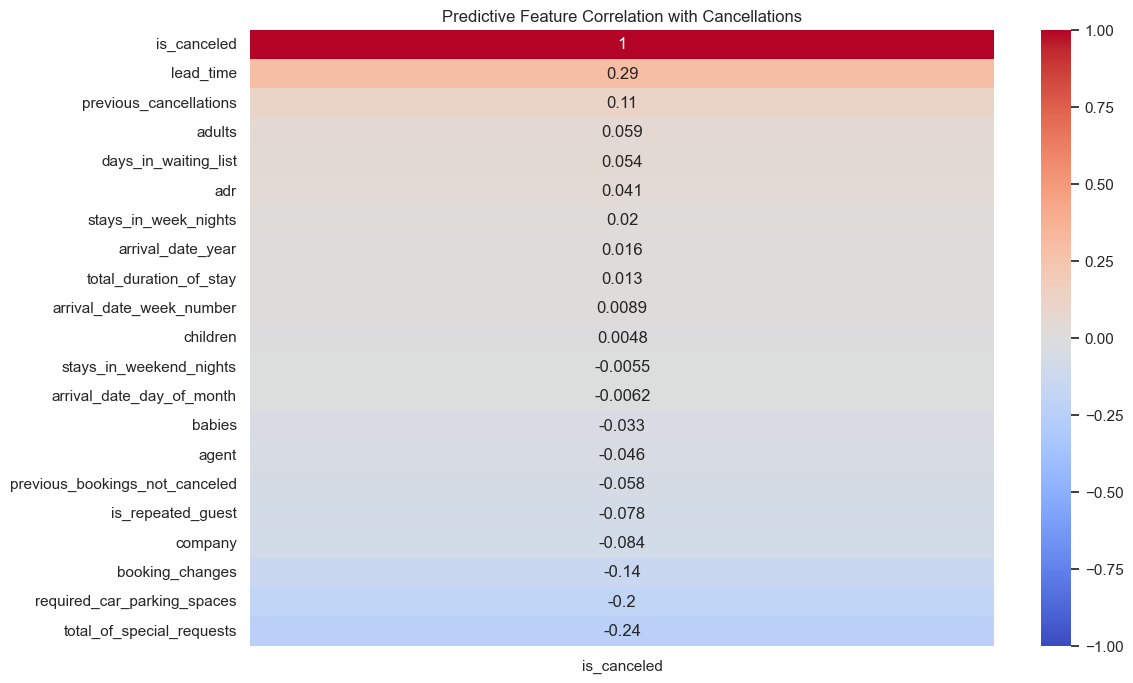

In [5]:

numerical_df = df.select_dtypes(include=['int64', 'float64', 'bool'])

plt.figure(figsize=(12, 8))

# here i want to Calculate the mathematical correlation
correlation_matrix = numerical_df.corr()

# Plot a heatmap 'is_canceled'
sns.heatmap(correlation_matrix[['is_canceled']].sort_values(by='is_canceled', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Predictive Feature Correlation with Cancellations")
plt.show()


## Day 5 Bivariate Analysis (Lead Time)
We will utilize a boxplot to investigate the correlation between `lead_time` (how many days in advance a booking was made) and
the likelihood of cancellation.

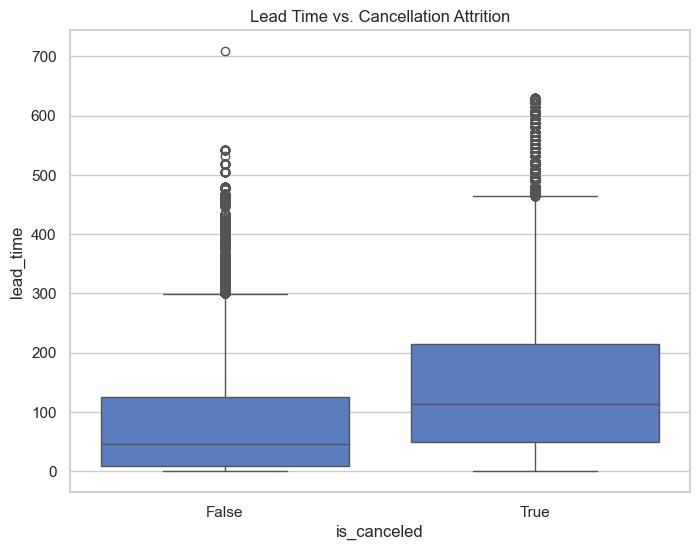

In [6]:
# Does booking further in advance lead to higher cancellations?
plt.figure(figsize=(8, 6))
# We use a boxplot to see the distribution of days
sns.boxplot(data=df, x='is_canceled', y='lead_time')
plt.title("Lead Time vs. Cancellation Attrition")
plt.show()

## Multivariate Analysis
We will perform a multivariate analysis to observe how `lead_time` interacts with different `market_segments`, and how that 
combined interaction affects our target variable (`is_canceled`).


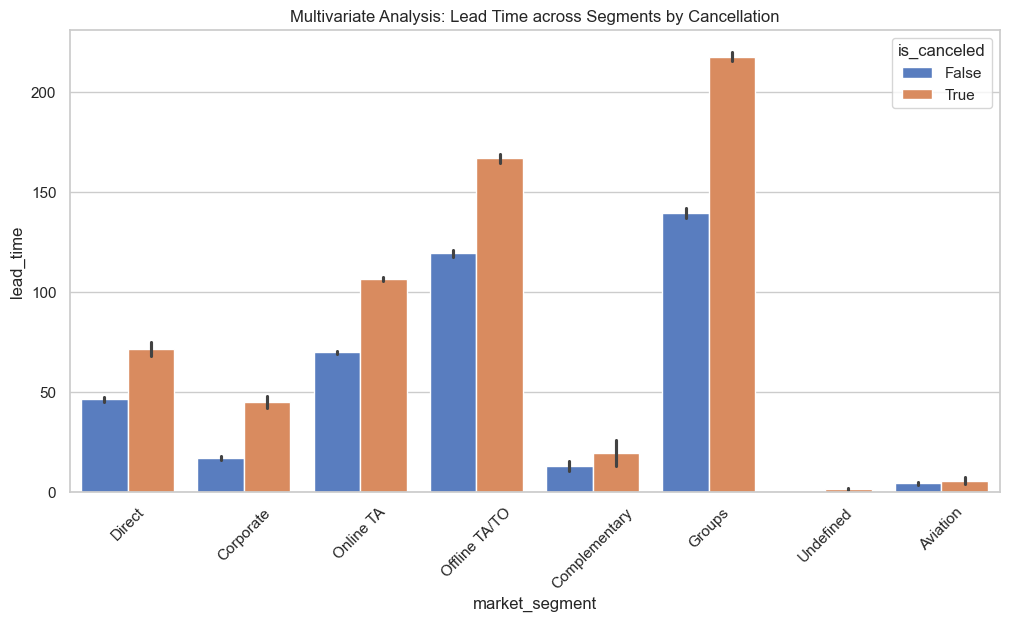

In [7]:
plt.figure(figsize=(12, 6))

# This barplot compares 3 variables: Market Segment (X), Lead Time (Y), and Cancellations (Colors)
sns.barplot(data=df, x='market_segment', y='lead_time', hue='is_canceled')

plt.title("Multivariate Analysis: Lead Time across Segments by Cancellation")
plt.xticks(rotation=45)
plt.show()


## Executive Summary: Customer Retention and Dynamic Pricing Analysis

 1. Strategic Objective
As part of the **Travel, Tourism & Hospitality** project, the objective of this Exploratory Data Analysis (EDA) was to uncover the hidden factors that drive hotel cancellations. By identifying these factors, we can build targeted customer retention campaigns and optimize dynamic pricing to prevent revenue loss.

 2. Analytical Findings
Using Seaborn and Matplotlib, we performed Univariate, Bivariate, and Multivariate analysis on our cleaned dataset and discovered the following churn drivers:

*   **Customer Retention Risk (Lead Time):** Our Boxplot and Multivariate Barplot prove that guests who book their room far in advance have the highest probability of canceling. Last-minute bookers rarely cancel.
*   **Dynamic Pricing Elasticity (ADR):** By analyzing the Average Daily Rate (ADR) distribution, we observed that premium-priced rooms suffer slightly higher cancellation rates than standard-priced rooms. 
*   **Segment Behavior:** Our Univariate Countplot reveals that Online Travel Agents (OTAs) drive the highest volume of bookings, but unfortunately also generate the highest volume of cancellations. Direct hotel bookings have much stronger customer retention.

 3. Next Steps: Predictive Modeling
Our **Correlation Heatmap** mathematically proved that `lead_time` is the #1 numerical predictor of cancellations. We will use this exact finding to train our Scikit-Learn Machine Learning model in Week 3!
